<h3>Derma-CNN</h3>

In [15]:
import os

def check_train_data(image_dir, mask_dir, image_suffix=".jpg", mask_suffix="_segmentation.png"):
    unmatched_images = []
    matched = []

    image_files = [f for f in os.listdir(image_dir) if f.endswith(image_suffix)]
    mask_files = [f for f in os.listdir(mask_dir) if f.endswith(mask_suffix)]
    
    for image_file in image_files:
        base_name = os.path.splitext(image_file)[0]
        mask_file = f"{base_name}{mask_suffix}"
        if mask_file in mask_files:
            matched.append((
                os.path.join(image_dir, image_file),
                os.path.join(mask_dir, mask_file)
            ))
        else:
            unmatched_images.append(image_file)
    
    return matched, unmatched_images

# Пример использования
image_dir = "data/TRAINING_IMAGES"
mask_dir = "data/TRAINING_MASKS"

matched, unmatched_images = check_train_data(image_dir, mask_dir)

print(f"Совпавшие пары: {len(matched)}")
print(f"Несовпавшие изображения: {unmatched_images[:5]}")

Совпавшие пары: 2594
Несовпавшие изображения: []


In [36]:
import os
import numpy as np
from tensorflow.keras.utils import Sequence
from PIL import Image
from sklearn.model_selection import train_test_split

class DataGenerator(Sequence):
    def __init__(self, image_paths, mask_paths, batch_size=4, target_size=(128, 128), augmentations=None, **kwargs):
        super().__init__(**kwargs)
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.target_size = target_size
        self.augmentations = augmentations

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, index):
        batch_images = self.image_paths[index * self.batch_size:(index + 1) * self.batch_size]
        batch_masks = self.mask_paths[index * self.batch_size:(index + 1) * self.batch_size]

        images, masks = [], []

        for img_path, mask_path in zip(batch_images, batch_masks):
            image = Image.open(img_path)
            image = image.resize(self.target_size)
            image = np.array(image) / 255.0 

            mask = Image.open(mask_path).convert("L")
            mask = mask.resize(self.target_size)
            mask = np.array(mask)
            mask = (mask > 0).astype(np.float32) 
            mask = np.expand_dims(mask, axis=-1)

            if self.augmentations:
                augmented = self.augmentations(image=image, mask=mask)
                image, mask = augmented['image'], augmented['mask']

            images.append(image)
            masks.append(mask)

        return np.array(images), np.array(masks)

train_img_paths, val_img_paths, train_mask_paths, val_mask_paths = train_test_split(
    [i[0] for i in matched], [i[1] for i in matched], test_size=0.2, random_state=42
)
# Создание генераторов
train_generator = DataGenerator(train_img_paths, train_mask_paths, batch_size=4, augmentations=None)
val_generator = DataGenerator(val_img_paths, val_mask_paths, batch_size=4)



In [37]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def unet_model(input_size=(128, 128, 3)):
    inputs = layers.Input(input_size)
    
    # Энкодер
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D((2, 2))(c4)

    # Боттлнек
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)

    # Декодер
    u6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c7)

    u8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c8)

    u9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c9)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)
    model = Model(inputs, outputs)
    return model

# Инициализация модели
model = unet_model()
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 128, 128,  │      1,792 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_38[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 64,    │          0 │ conv2d_39[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_40[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 32,    │          0 │ conv2d_41[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_9[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_42[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 16, 16,    │          0 │ conv2d_43[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_10… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 16, 16,    │  2,359,808 │ conv2d_44[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 8, 8, 512) │          0 │ conv2d_45[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_11… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 8, 8,      │  9,438,208 │ conv2d_46[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 16, 16,    │  2,097,664 │ conv2d_47[0][0]   │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
import tensorflow.keras.backend as K
#реализация Dice Loss
def dice_loss(y_true, y_pred):
    smooth = 1.0
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [39]:
#Dice Coefficient
def dice_coefficient(y_true, y_pred):
    smooth = 1.0
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [40]:
#настройка модели
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=dice_loss,
    metrics=[dice_coefficient]
)

In [60]:
import os
import cv2
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
import albumentations as A
from tensorflow.keras.utils import Sequence

class SegmentationDataGenerator(Sequence):
    def __init__(self, img_dir, mask_dir, filenames, batch_size=4, 
                 target_size=(128, 128), augment=False, shuffle=True):
        self.img_dir = Path(img_dir)
        self.mask_dir = Path(mask_dir)
        self.filenames = filenames
        self.batch_size = batch_size
        self.target_size = target_size
        self.augment = augment
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.filenames))
        
        self.augmentation = A.Compose([
            A.Rotate(limit=30, p=0.5),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.5),
            A.GaussianBlur(blur_limit=(3, 7), p=0.3),
            A.GridDistortion(p=0.3),
        ], additional_targets={'mask': 'mask'})
        
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.filenames) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        batch_filenames = [self.filenames[i] for i in batch_indexes]
        
        X = np.zeros((len(batch_filenames), *self.target_size, 3), dtype=np.float32)
        y = np.zeros((len(batch_filenames), *self.target_size, 1), dtype=np.float32)
        
        for i, filename in enumerate(batch_filenames):
            img_path = self.img_dir / f"{filename}.jpg"
            mask_path = self.mask_dir / f"{filename}_segmentation.png"
            
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
            
            img = cv2.resize(img, self.target_size)
            mask = cv2.resize(mask, self.target_size)
            
            if self.augment:
                augmented = self.augmentation(image=img, mask=mask)
                img, mask = augmented['image'], augmented['mask']
            
            X[i] = img / 255.0
            y[i] = np.expand_dims(mask, axis=-1) / 255.0
            
        return X, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

def validate_file_pairs(img_dir, mask_dir, mask_suffix='_segmentation'):
    img_files = {f.stem for f in Path(img_dir).glob('*.jpg') if not f.name.startswith('.')}
    mask_files = {f.name.replace(mask_suffix, '').replace('.png', '') 
                 for f in Path(mask_dir).glob('*.png') if not f.name.startswith('.')}
    
    common = sorted(list(img_files & mask_files))
    only_img = img_files - mask_files
    only_mask = mask_files - img_files
    
    print(f"\nПроверка соответствия файлов:")
    print(f"Совпадающих пар: {len(common)}")
    print(f"Только изображений: {len(only_img)}")
    print(f"Только масок: {len(only_mask)}")
    
    if not common:
        raise ValueError("Нет совпадающих пар изображение-маска!")
    
    return common

def prepare_datasets():
    matched_files = validate_file_pairs(
        img_dir='data/TRAINING_IMAGES',
        mask_dir='data/TRAINING_MASKS'
    )
    
    train_files, val_files = train_test_split(
        matched_files, 
        test_size=0.2, 
        random_state=42
    )
    
    train_gen = SegmentationDataGenerator(
        img_dir='data/TRAINING_IMAGES',
        mask_dir='data/TRAINING_MASKS',
        filenames=train_files,
        batch_size=4,
        augment=True,
        shuffle=True
    )
    
    val_gen = SegmentationDataGenerator(
        img_dir='data/TRAINING_IMAGES',
        mask_dir='data/TRAINING_MASKS',
        filenames=val_files,
        batch_size=4,
        augment=False,
        shuffle=False
    )
    
    return train_gen, val_gen

def test_generator(generator, name):
    print(f"\nТестирование {name} генератора:")
    try:
        X, y = generator[0]
        print(f"Размер батча изображений: {X.shape}")
        print(f"Размер батча масок: {y.shape}")
        print(f"Диапазон значений изображений: {X.min():.2f}-{X.max():.2f}")
        print(f"Диапазон значений масок: {y.min():.2f}-{y.max():.2f}")
    except Exception as e:
        print(f"Ошибка тестирования: {str(e)}")

if __name__ == "__main__":
    train_generator, val_generator = prepare_datasets()
    test_generator(train_generator, "train")
    test_generator(val_generator, "validation")



Проверка соответствия файлов:
Совпадающих пар: 2594
Только изображений: 0
Только масок: 0

Тестирование train генератора:
Размер батча изображений: (4, 128, 128, 3)
Размер батча масок: (4, 128, 128, 1)
Диапазон значений изображений: 0.00-1.00
Диапазон значений масок: 0.00-1.00

Тестирование validation генератора:
Размер батча изображений: (4, 128, 128, 3)
Размер батча масок: (4, 128, 128, 1)
Диапазон значений изображений: 0.00-1.00
Диапазон значений масок: 0.00-1.00


In [61]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# Используем ранее созданные списки путей (matched pairs)
train_img_paths, val_img_paths, train_mask_paths, val_mask_paths = train_test_split(
    [i[0] for i in matched], [i[1] for i in matched], test_size=0.2, random_state=42
)

# Функция для загрузки и предобработки изображений
def load_and_preprocess(img_path, mask_path, target_size=(128, 128)):
    # Загрузка изображения
    img = Image.open(img_path).resize(target_size)
    img = np.array(img) / 255.0
    
    # Загрузка маски
    mask = Image.open(mask_path).convert('L').resize(target_size)
    mask = (np.array(mask) > 0).astype(np.float32)
    mask = np.expand_dims(mask, axis=-1)  # Добавляем размерность канала
    
    return img, mask

# Генератор данных с аугментациями
class CustomDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, img_paths, mask_paths, batch_size=4, target_size=(128, 128), augment=False, **kwargs):
        super().__init__(**kwargs)
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.target_size = target_size
        self.augment = augment
        self.indices = np.arange(len(self.img_paths))
        
        # Аугментации
        self.image_datagen = ImageDataGenerator(
            rotation_range=15,
            width_shift_range=0.1,
            height_shift_range=0.1,
            shear_range=0.1,
            zoom_range=0.1,
            horizontal_flip=True,
            fill_mode='nearest'
        )
        
    def __len__(self):
        return len(self.img_paths) // self.batch_size
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        batch_img = []
        batch_mask = []
        
        for i in batch_indices:
            img, mask = load_and_preprocess(self.img_paths[i], self.mask_paths[i], self.target_size)
            
            if self.augment:
                # Применяем одинаковые аугментации к изображению и маске
                stacked = np.concatenate([img, mask], axis=-1)
                augmented = self.image_datagen.random_transform(stacked)
                img = augmented[..., :3]
                mask = augmented[..., 3:]
                mask = (mask > 0.5).astype(np.float32)  # Бинаризуем после аугментации
                
            batch_img.append(img)
            batch_mask.append(mask)
            
        return np.array(batch_img), np.array(batch_mask)
    
    def on_epoch_end(self):
        np.random.shuffle(self.indices)

# Создание генераторов
train_gen = CustomDataGenerator(train_img_paths, train_mask_paths, augment=True)
val_gen = CustomDataGenerator(val_img_paths, val_mask_paths)

# Обучение модели
history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    verbose=1
)

Epoch 1/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 530s 1s/step - dice_coefficient: 0.3717 - loss: 0.6283 - val_dice_coefficient: 0.6838 - val_loss: 0.3162
Epoch 2/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 513s 991ms/step - dice_coefficient: 0.6606 - loss: 0.3394 - val_dice_coefficient: 0.7454 - val_loss: 0.2546
Epoch 3/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 540s 1s/step - dice_coefficient: 0.7646 - loss: 0.2354 - val_dice_coefficient: 0.7940 - val_loss: 0.2060
Epoch 4/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 922s 2s/step - dice_coefficient: 0.7824 - loss: 0.2176 - val_dice_coefficient: 0.8004 - val_loss: 0.1996
Epoch 5/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 529s 1s/step - dice_coefficient: 0.7890 - loss: 0.2110 - val_dice_coefficient: 0.8062 - val_loss: 0.1938
Epoch 6/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 631s 1s/step - dice_coefficient: 0.8094 - loss: 0.1906 - val_dice_coefficient: 0.8102 - val_loss: 0.1898
Epoch 7/20
518/518 ━━━━━━━━━━━━━━━━━━━━ 1315s 3s/step - dice_coefficient: 0.8099 - loss: 0.1901 - val_dice_coefficient: 0.8266 

In [77]:
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Генератор для тестовых изображений
test_image_gen = test_datagen.flow_from_directory(
    'data/TEST_IMAGES',
    target_size=(128, 128),
    batch_size=8,
    classes=[''],
    class_mode=None,
    shuffle=False,
    seed=42
)

# Генератор для тренировочных масок
train_mask_gen = test_datagen.flow_from_directory(
    'data/TRAINING_MASKS', 
    target_size=(128, 128),
    batch_size=8,
    class_mode=None,
    classes=[''],
    color_mode='grayscale',
    shuffle=False,
    seed=42
)

test_gen = combine_generator(test_image_gen, train_mask_gen)

Found 1000 images belonging to 1 classes.
Found 2594 images belonging to 1 classes.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


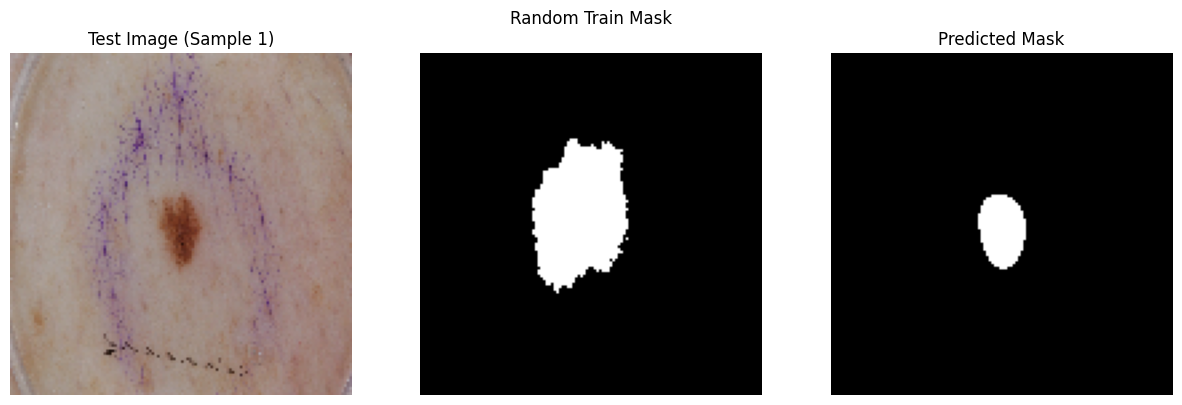

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


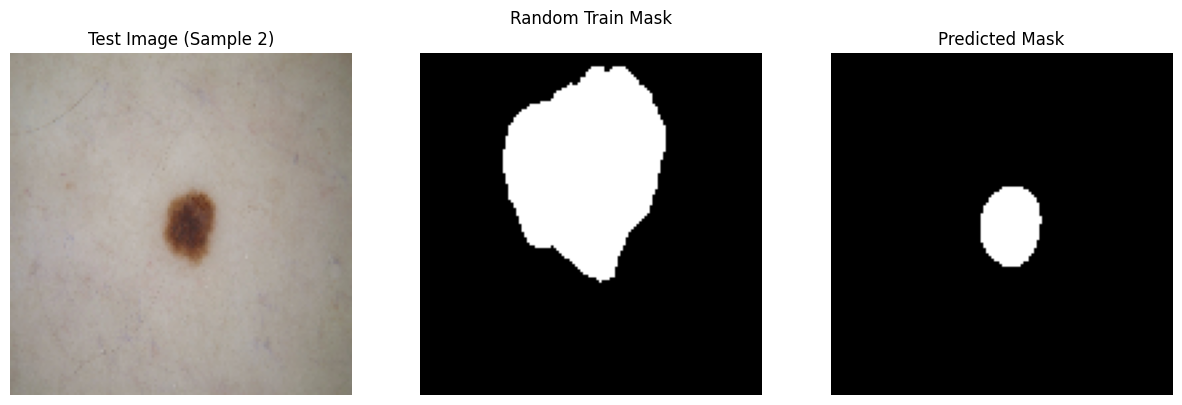

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


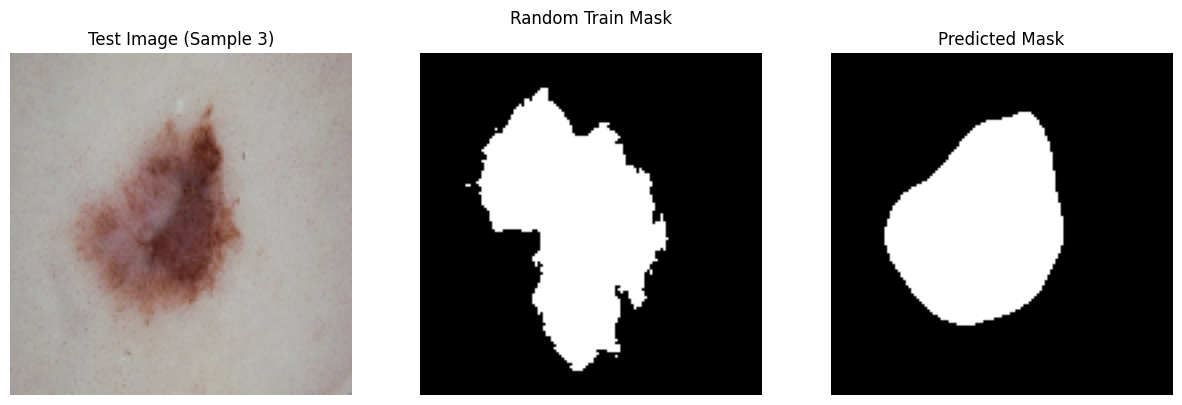

In [84]:
import random

def visualize_comparison(model, image_gen, mask_gen, num_samples=3):
    image_gen.reset()
    mask_gen.reset()
    
    for i in range(num_samples):
        test_images = next(image_gen)
        train_masks = next(mask_gen)
        
        random_idx = random.randint(0, len(test_images)-1)
        
        test_img = test_images[random_idx]
        random_train_mask = train_masks[random_idx]
        
        # Предсказание модели
        pred_mask = model.predict(test_img[np.newaxis, ...])[0]
        pred_mask = (pred_mask > 0.5).astype(np.float32)

        # Визуализация
        plt.figure(figsize=(15, 5))
        
        plt.subplot(1, 3, 1)
        plt.imshow(test_img)
        plt.title(f"Test Image (Sample {i+1})")
        plt.axis('off')
        
        plt.subplot(1, 3, 2)
        plt.imshow(random_train_mask.squeeze(), cmap='gray')
        plt.title("Random Train Mask\n")
        plt.axis('off')
        
        plt.subplot(1, 3, 3)
        plt.imshow(pred_mask.squeeze(), cmap='gray')
        plt.title("Predicted Mask")
        plt.axis('off')
        
        plt.show()
        
visualize_comparison(model, test_image_gen, train_mask_gen)

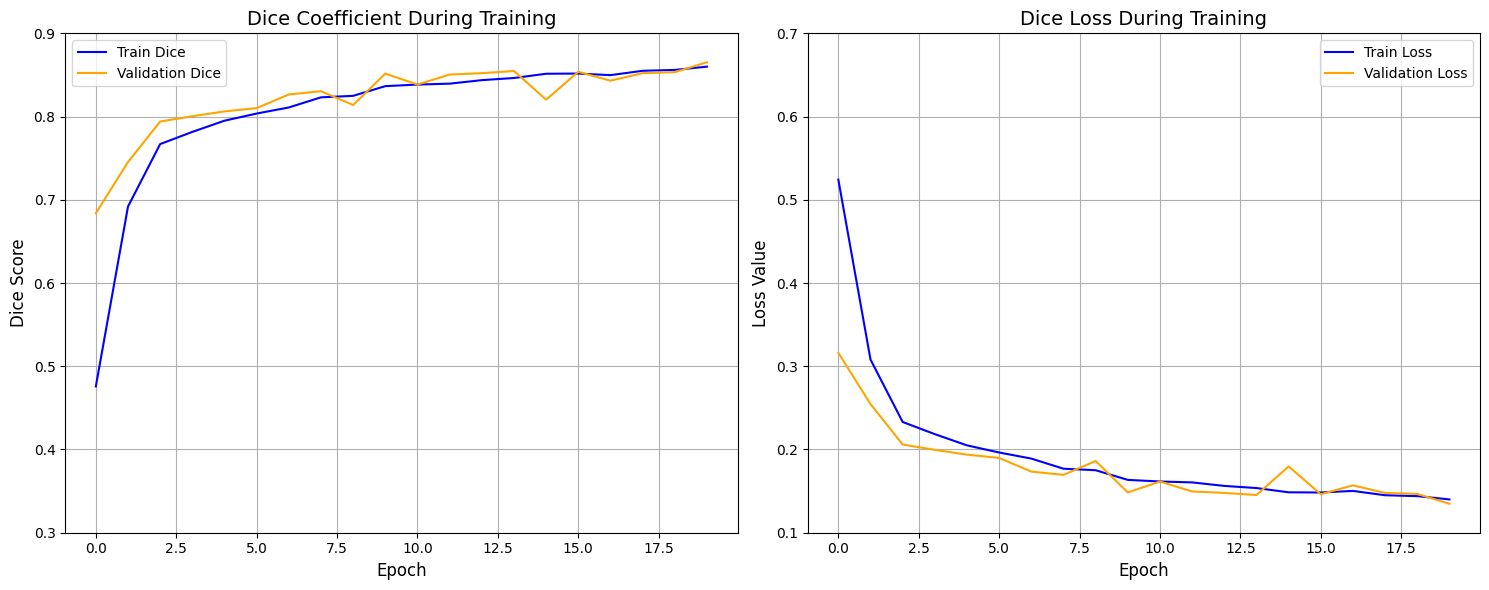


Тестовый генератор отсутствует


In [92]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(15, 6))
    
    # График Dice Coefficient
    plt.subplot(1, 2, 1)
    plt.plot(history.history['dice_coefficient'], label='Train Dice', color='blue')
    plt.plot(history.history['val_dice_coefficient'], label='Validation Dice', color='orange')
    plt.title('Dice Coefficient During Training', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Dice Score', fontsize=12)
    plt.ylim(0.3, 0.9)
    plt.legend()
    plt.grid(True)
    
    # График Dice Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss', color='blue')
    plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Dice Loss During Training', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss Value', fontsize=12)
    plt.ylim(0.1, 0.7)
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Вызов функции для отрисовки графиков
plot_training_history(history)

# Оценка на тестовых данных
try:
    test_loss, test_dice = model.evaluate(test_gen, verbose=0)
    print(f"\nFinal Test Metrics:")
    print(f"Dice Coefficient: {test_dice:.4f}")
    print(f"Dice Loss: {test_loss:.4f}")
except:
    print("\nТестовый генератор отсутствует")